In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\SuNi\Downloads\heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
df['HeartDisease'] = (df['num'] > 0).astype(int)
df = df.drop(['id', 'dataset', 'num'], axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,HeartDisease
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


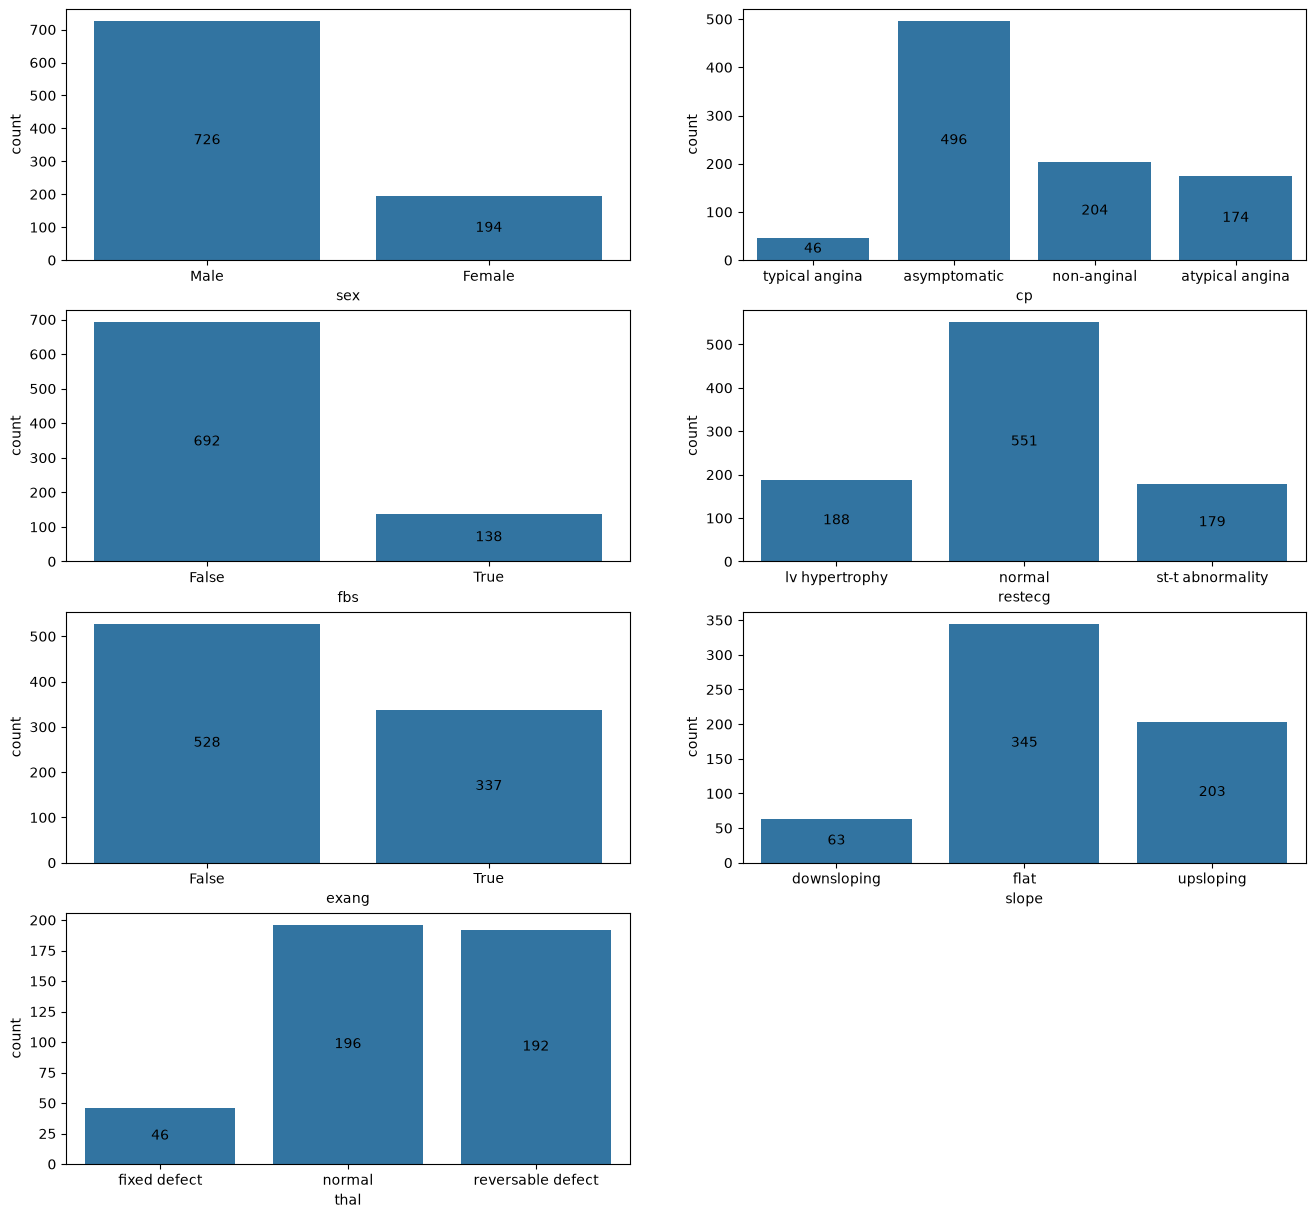

In [3]:
word_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
 
plt.figure(figsize=(16, 15))
for idx, col in enumerate(word_cols):
    ax = plt.subplot(4, 2, idx+1)
    sns.countplot(x=df[col], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

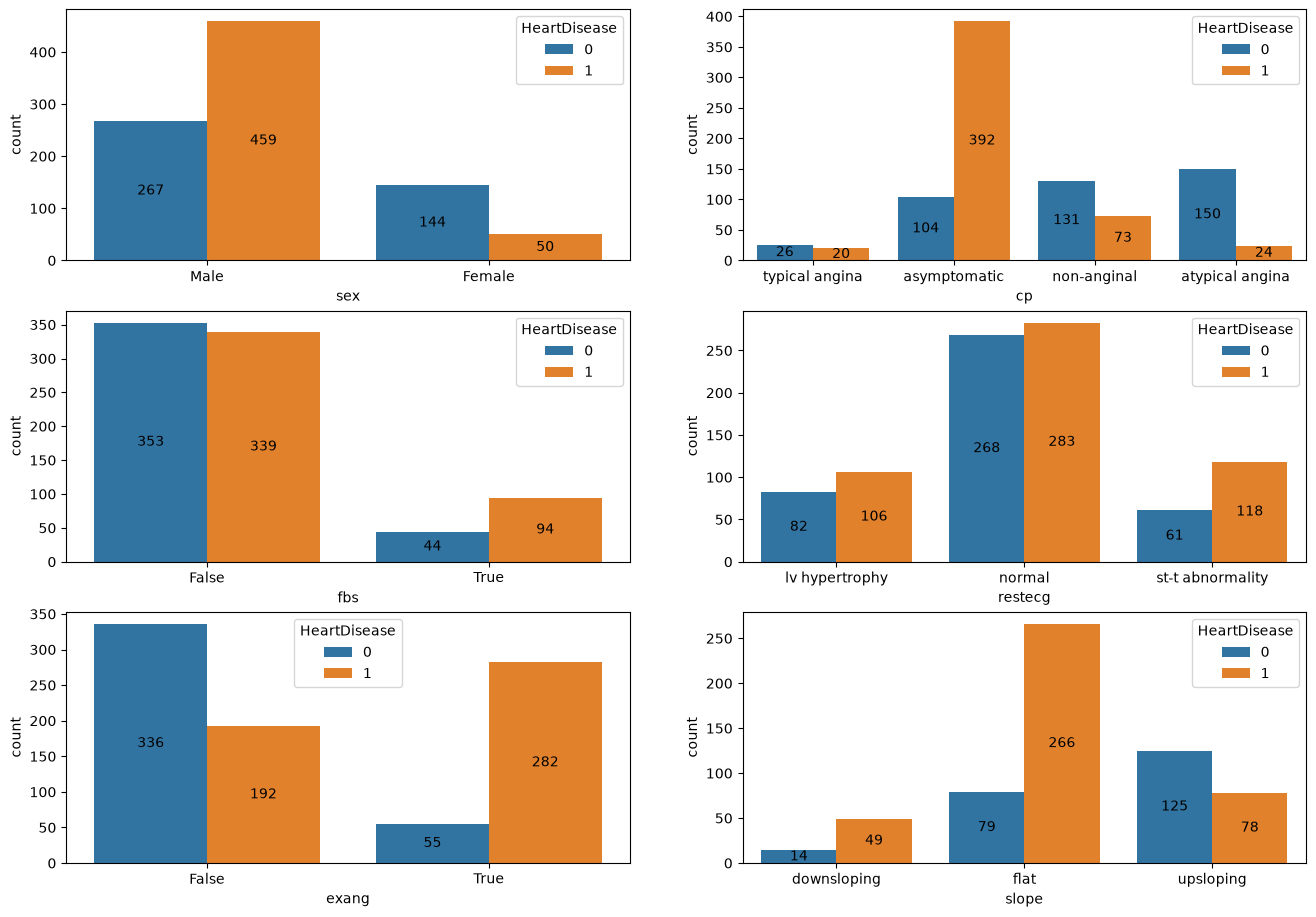

In [4]:
plt.figure(figsize=(16, 15))
for idx, col in enumerate(word_cols[:-1]):
    ax = plt.subplot(4, 2, idx+1)
    sns.countplot(x=df[col], hue=df['HeartDisease'], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           920 non-null    int64  
 1   sex           920 non-null    str    
 2   cp            920 non-null    str    
 3   trestbps      861 non-null    float64
 4   chol          890 non-null    float64
 5   fbs           830 non-null    object 
 6   restecg       918 non-null    str    
 7   thalch        865 non-null    float64
 8   exang         865 non-null    object 
 9   oldpeak       858 non-null    float64
 10  slope         611 non-null    str    
 11  ca            309 non-null    float64
 12  thal          434 non-null    str    
 13  HeartDisease  920 non-null    int64  
dtypes: float64(5), int64(2), object(2), str(5)
memory usage: 133.5+ KB


In [59]:
word_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in word_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

encoders = {}
for col in word_cols:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col].astype(str))

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,HeartDisease
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,HeartDisease
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,0.789130,0.782609,131.995652,199.908696,0.345652,0.994565,137.692391,0.485870,0.853261,1.823913,0.227174,2.215217,0.553261
std,9.424685,0.408148,0.956350,18.451300,109.040171,0.649837,0.638767,25.145235,0.608085,1.058049,0.977146,0.628936,0.946551,0.497426
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,177.750000,0.000000,1.000000,120.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,1.000000,140.000000,0.000000,0.500000,2.000000,0.000000,3.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,3.000000,0.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,2.000000,3.000000,202.000000,2.000000,6.200000,3.000000,3.000000,3.000000,1.000000


In [60]:
df.isnull().any()

age             False
sex             False
cp              False
trestbps        False
chol            False
fbs             False
restecg         False
thalch          False
exang           False
oldpeak         False
slope           False
ca              False
thal            False
HeartDisease    False
dtype: bool

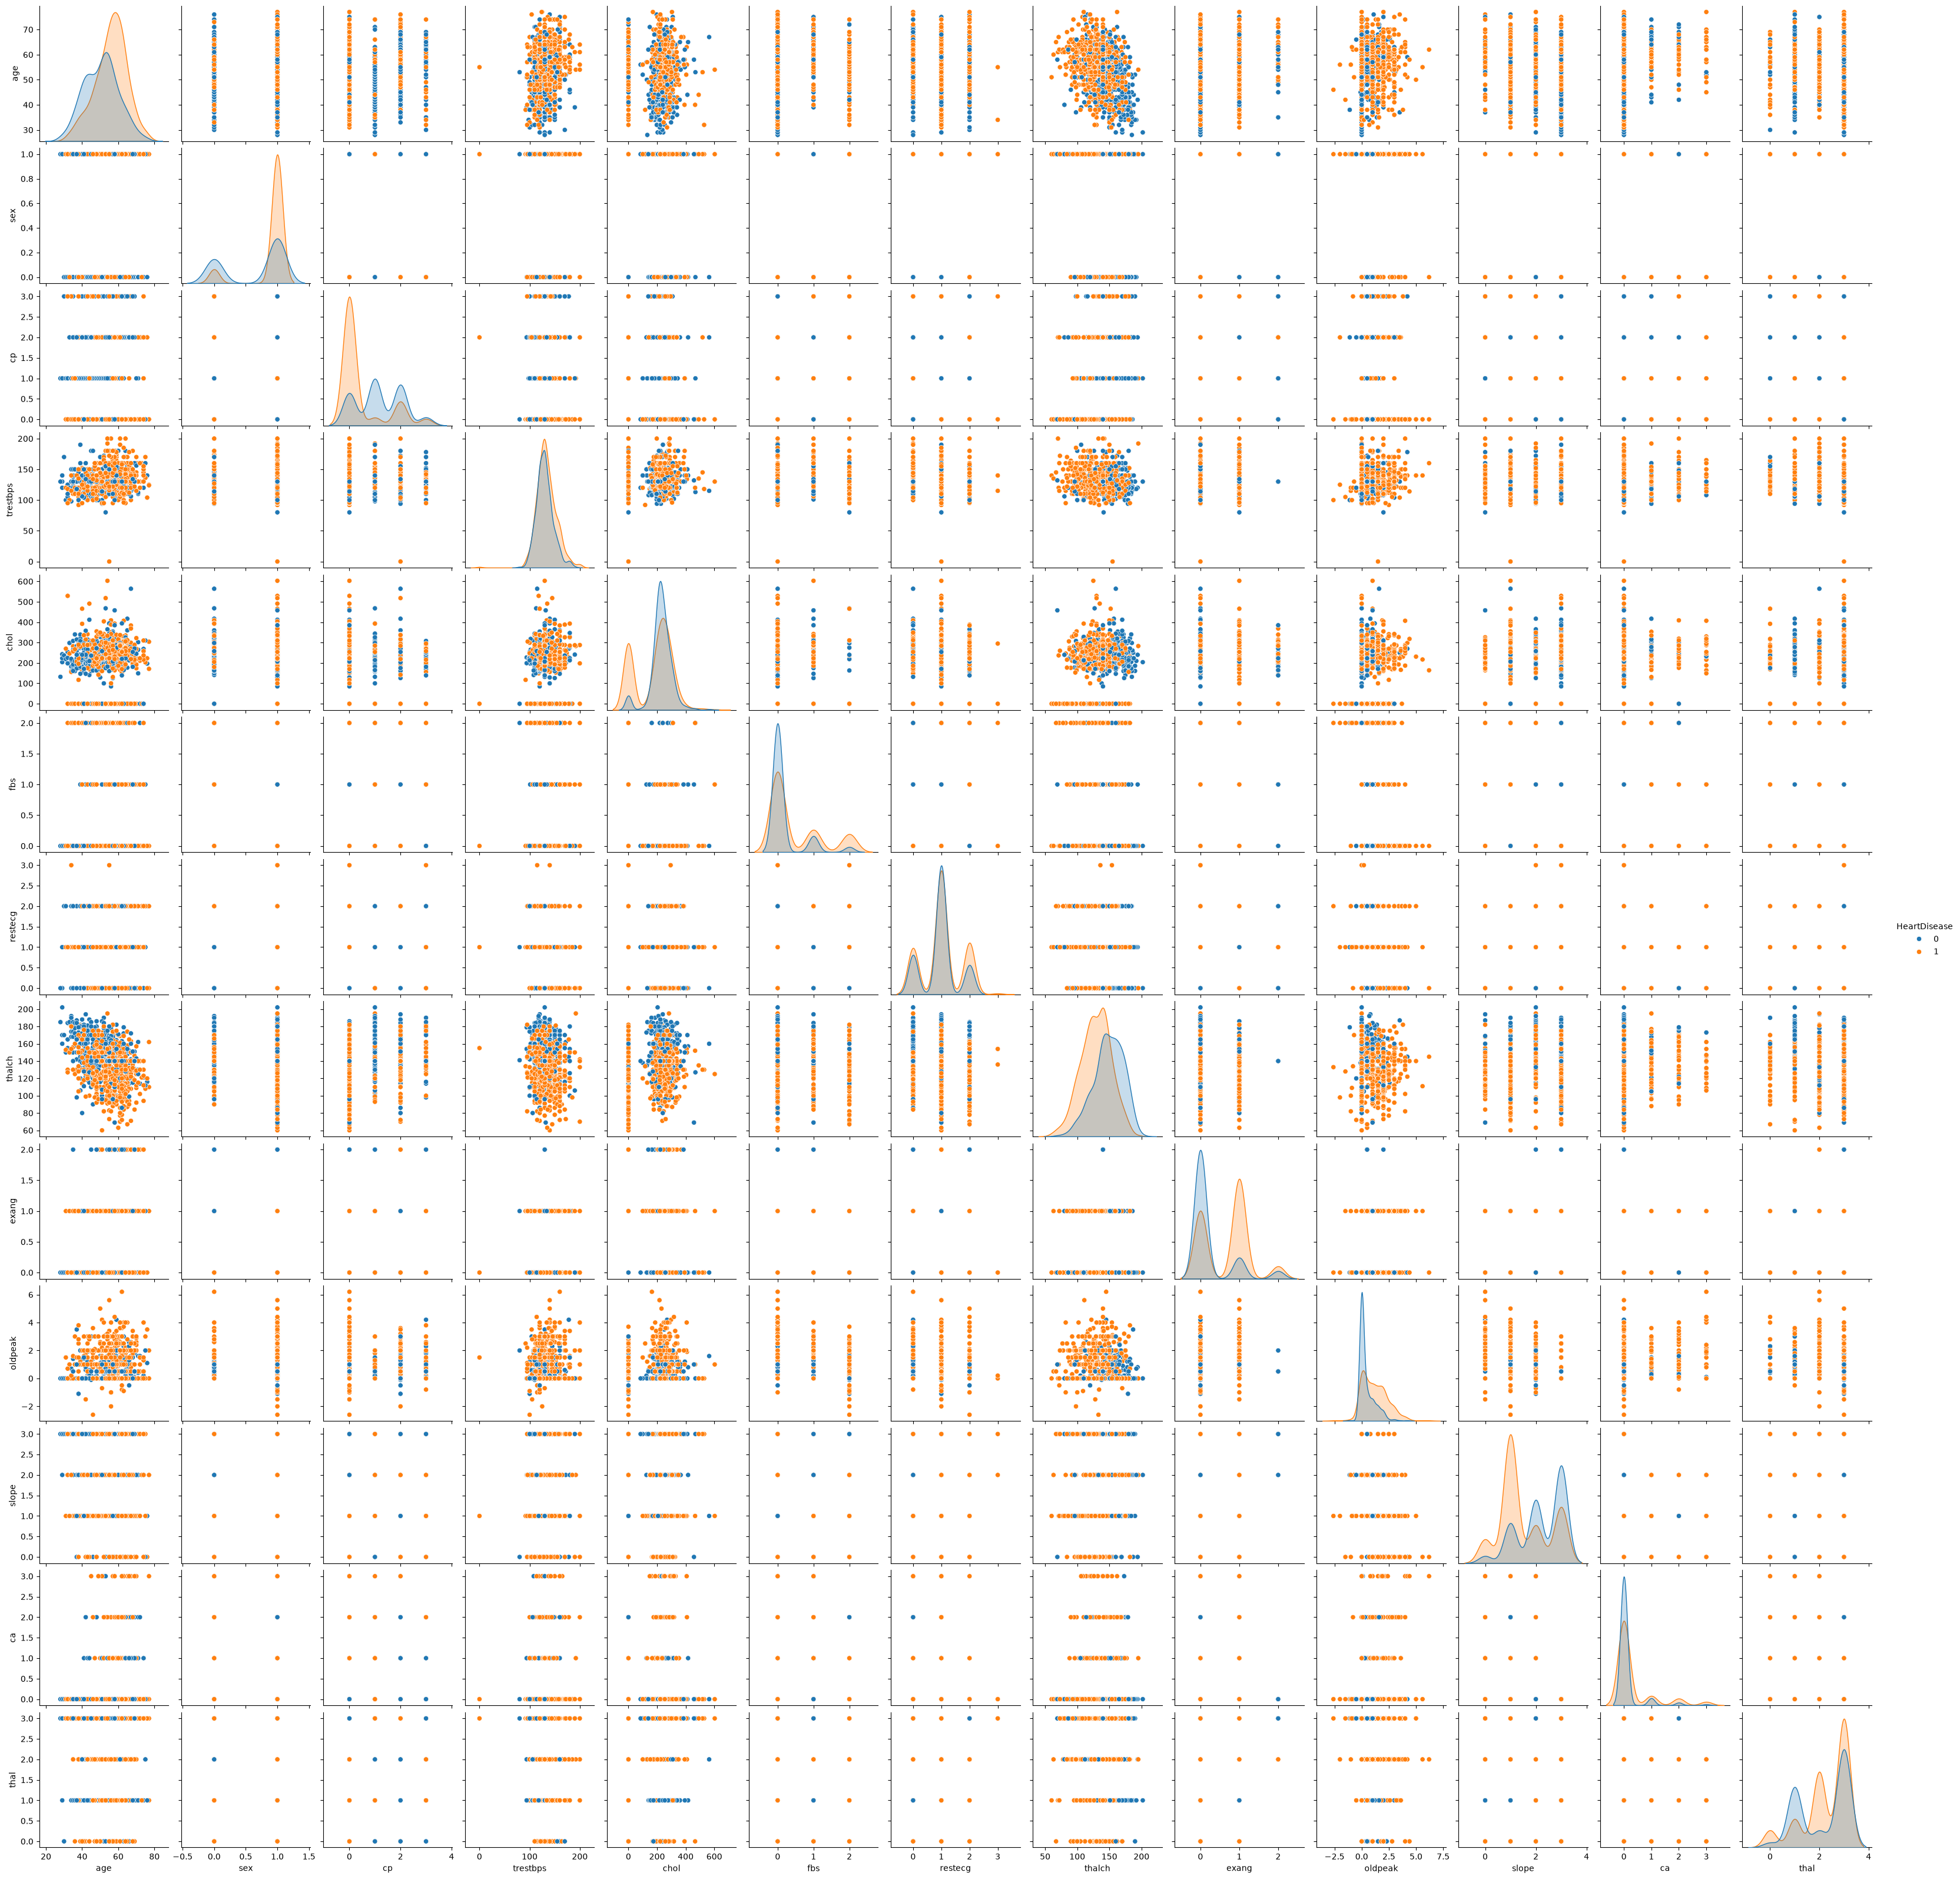

In [61]:
sns.pairplot(df, hue='HeartDisease')

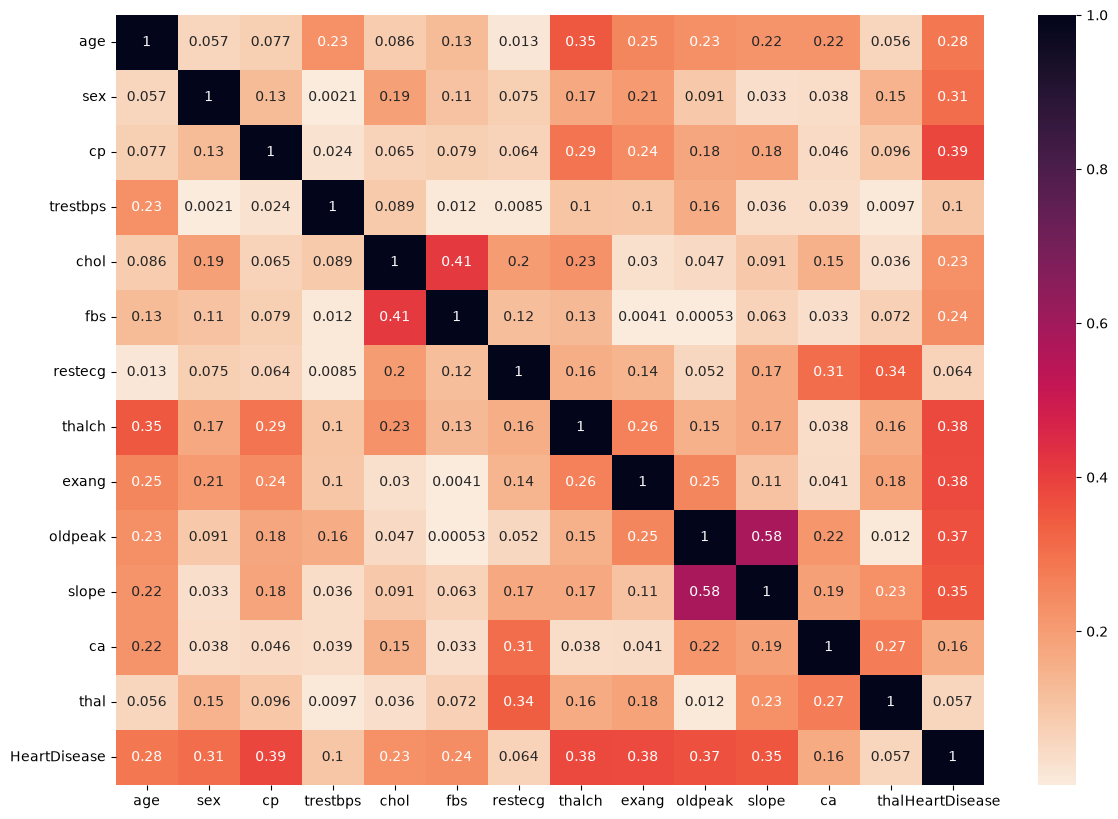

In [62]:
plt.figure(figsize=(14, 10))
corr = abs(df.corr())
sns.heatmap(corr, annot=True, cmap='rocket_r')
plt.show()

In [63]:
X = df.drop(['HeartDisease'], axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    'Perceptron': Perceptron(max_iter=1000, random_state=42),
    'Logistic Regression': LogisticRegression(),
    'MLP': MLPClassifier(hidden_layer_sizes=(16,8), max_iter=2000, random_state=42)
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred=m.predict(X_test)
    print(f'\n---{name}---')
    print('Accuracy Score:',round(accuracy_score(y_test, pred), 4))
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))


---Perceptron---
Accuracy Score: 0.712
[[39 43]
 [10 92]]
              precision    recall  f1-score   support

           0       0.80      0.48      0.60        82
           1       0.68      0.90      0.78       102

    accuracy                           0.71       184
   macro avg       0.74      0.69      0.69       184
weighted avg       0.73      0.71      0.70       184


---Logistic Regression---
Accuracy Score: 0.8098
[[63 19]
 [16 86]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.78        82
           1       0.82      0.84      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184


---MLP---
Accuracy Score: 0.8043
[[59 23]
 [13 89]]
              precision    recall  f1-score   support

           0       0.82      0.72      0.77        82
           1       0.79      0.87      0.83       102

 

In [64]:
print('\n--- Training Deep Artificial Neural Network (ANN) ---')

model_ann = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_ann = model_ann.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 50,
    batch_size = 8,
    verbose = 1
)

test_loss, test_acc = model_ann.evaluate(X_test, y_test, verbose=0)
predicts = model_ann.predict(X_test, verbose=0).argmax(axis=1)

print(f'\n---Model Performance---')
print(f'Test Accuracy: {test_acc:.4f}\n')
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")


--- Training Deep Artificial Neural Network (ANN) ---
Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5459 - loss: 0.9933 - val_accuracy: 0.7162 - val_loss: 0.8367
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7330 - loss: 0.7531 - val_accuracy: 0.7905 - val_loss: 0.6432
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7857 - loss: 0.5987 - val_accuracy: 0.8176 - val_loss: 0.5236
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8010 - loss: 0.5112 - val_accuracy: 0.8311 - val_loss: 0.4658
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8112 - loss: 0.4685 - val_accuracy: 0.8243 - val_loss: 0.4439
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8231 - loss: 0.4463 - val_accuracy: 0.8311 - val_loss: 0.4357
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8231 - loss: 0.4335 - val_accuracy: 0.8378 - val_loss: 0.4319
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 

In [ ]:
print('\n--- Training 2D Convolutional Neural Network (CNN) ---')

n_features = np.asarray(X_test).reshape(len(X_test), -1).shape[1]
side = int(np.ceil(np.sqrt(n_features)))

def to_image(X):
    X = np.asarray(X).reshape(len(X), -1)[:,:n_features]
    X = np.pad(X, ((0,0),(0, side*side-n_features)))
    return X.reshape(-1, side, side, 1)

X_train_cnn = to_image(X_train)
X_test_cnn = to_image(X_test)

model_cnn = keras.Sequential([
    layers.Input(shape=(side, side, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    validation_split = 0.2,
    epochs = 50,
    batch_size = 8,
    verbose = 1
)

test_loss, test_acc = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
predicts = np.argmax(model_cnn.predict(X_test_cnn, verbose=0),axis=1)

print(f'\n---Model Performance---')
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")


--- Training 2D Convolutional Neural Network (CNN) ---
Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7840 - loss: 0.4781 - val_accuracy: 0.8176 - val_loss: 0.4087
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8112 - loss: 0.4323 - val_accuracy: 0.8243 - val_loss: 0.4026
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8316 - loss: 0.3947 - val_accuracy: 0.8446 - val_loss: 0.4250
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8469 - loss: 0.3868 - val_accuracy: 0.8446 - val_loss: 0.4307
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8384 - loss: 0.3739 - val_accuracy: 0.8176 - val_loss: 0.4038
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8656 - loss: 0.3355 - val_accuracy: 0.8041 - val_loss: 0.4586
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8741 - loss: 0.3161 - val_accuracy: 0.8243 - val_loss: 0.4425
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - ac

In [72]:
print('\n--- Training Recurrent Neural Network (RNN) ---')

n_features = np.asarray(X_test).reshape(len(X_test), -1).shape[1]
X_train_rnn = np.asarray(X_train).reshape(len(X_train), -1)[:,:n_features].reshape(-1, n_features, 1)
X_test_rnn = np.asarray(X_test).reshape(len(X_test), -1)[:,:n_features].reshape(-1, n_features, 1)


model_rnn = keras.Sequential([
    layers.Input(shape=(n_features,1)),
    layers.SimpleRNN(64, activation='tanh', return_sequences=True),
    layers.Dropout(0.3),
    layers.SimpleRNN(32, activation='tanh'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_rnn = model_rnn.fit(
    X_train_rnn, y_train,
    validation_split = 0.2,
    epochs = 50,
    batch_size = 8,
    verbose = 1
)

test_loss, test_acc = model_rnn.evaluate(X_test_rnn, y_test, verbose=0)
predicts = model_rnn.predict(X_test_rnn).argmax(axis=1)

print(f'\n---Model Performance---')
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")


--- Training Recurrent Neural Network (RNN) ---
Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7636 - loss: 0.5196 - val_accuracy: 0.8176 - val_loss: 0.4263
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8044 - loss: 0.4542 - val_accuracy: 0.7770 - val_loss: 0.5093
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7993 - loss: 0.4584 - val_accuracy: 0.8108 - val_loss: 0.4539
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7959 - loss: 0.4454 - val_accuracy: 0.8176 - val_loss: 0.4529
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8129 - loss: 0.4339 - val_accuracy: 0.8176 - val_loss: 0.4488
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8129 - loss: 0.4084 - val_accuracy: 0.8243 - val_loss: 0.4523
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8146 - loss: 0.4420 - val_accuracy: 0.8176 - val_loss: 0.4637
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy:

In [67]:
def plot_training(history, title):
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train_acc')
    plt.plot(history.history['val_accuracy'], label='Val_acc')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

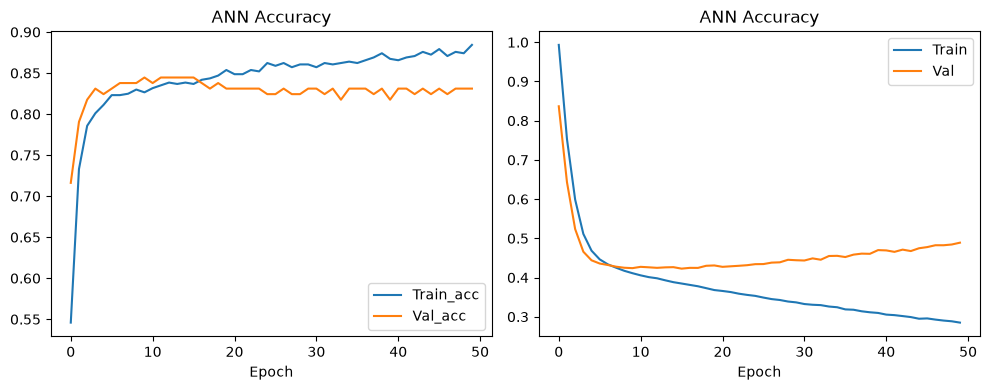

In [68]:
plot_training(history_ann, "ANN")

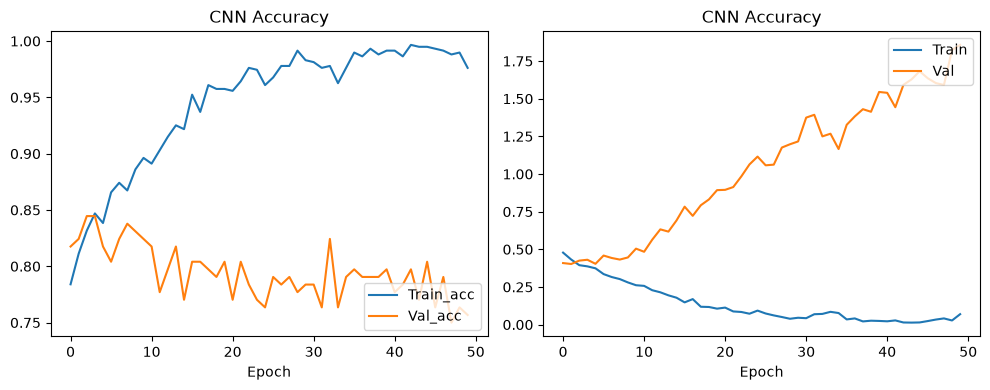

In [69]:
plot_training(history_cnn, "CNN")

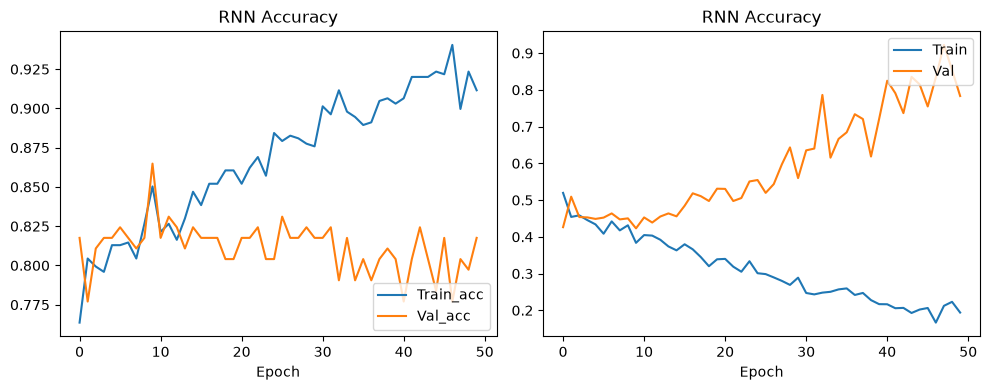

In [74]:
plot_training(history_rnn, "RNN")

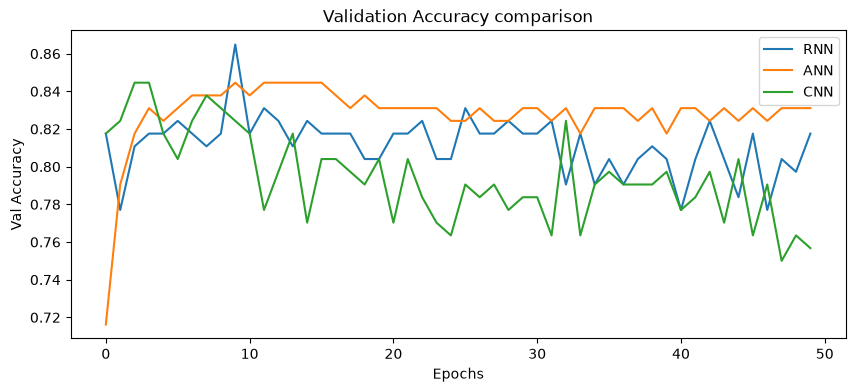

In [73]:
plt.figure(figsize=(10,4))
plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_ann.history['val_accuracy'], label='ANN')
plt.plot(history_cnn.history['val_accuracy'], label='CNN')
plt.title('Validation Accuracy comparison')
plt.xlabel('Epochs')
plt.ylabel('Val Accuracy')
plt.legend()
plt.show()